# Differentially Private Logistic Regression - Lung Cancer Dataset

This notebook trains a differentially private Logistic Regression (via IBM diffprivlib) on the Lung Cancer dataset (50,000 samples, 23 features, 3-class target).

Privacy budget (ε) ∈ {0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0}
Each epsilon value is evaluated over 30 independent runs.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from diffprivlib.models import LogisticRegression as DPLogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
bounds = data['bounds']
n_classes = data.get('n_classes', 3)

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {n_classes}")

Training set: (40000, 23)
Test set: (10000, 23)
Number of features: 23
Number of classes: 3


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('./output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: output/baseline_results.csv not found. Run STD_LR.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 1.0000
Baseline F1-Score: 1.0000


## 4. Quick Demo at ε=1.0 (30 Runs)

In [4]:
epsilon = 1.0
N_RUNS = 30

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []

print(f"Training DP Logistic Regression {N_RUNS} times with epsilon={epsilon}...")
print("=" * 80)

detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42

    dp_model = DPLogisticRegression(
        epsilon=epsilon,
        max_iter=1000,
        random_state=seed,
        multi_class='ovr',
        data_norm=1.0
    )

    _t0 = time.perf_counter()
    dp_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_pred = dp_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    detail_extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

print("=" * 80)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {np.mean(detail_accuracies):.4f} +/- {np.std(detail_accuracies):.4f}")
print(f"  F1-Score:  {np.mean(detail_f1s):.4f} +/- {np.std(detail_f1s):.4f}")
print(f"  Precision: {np.mean(detail_precisions):.4f} +/- {np.std(detail_precisions):.4f}")
print(f"  Recall:    {np.mean(detail_recalls):.4f} +/- {np.std(detail_recalls):.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Logistic Regression 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.9794 | F1: 0.9792 | Prec: 0.9800 | Rec: 0.9794
  Run  2/30 | Acc: 0.9707 | F1: 0.9707 | Prec: 0.9709 | Rec: 0.9707


  Run  3/30 | Acc: 0.9764 | F1: 0.9763 | Prec: 0.9776 | Rec: 0.9764


  Run  4/30 | Acc: 0.9790 | F1: 0.9790 | Prec: 0.9802 | Rec: 0.9790
  Run  5/30 | Acc: 0.9789 | F1: 0.9787 | Prec: 0.9794 | Rec: 0.9789
  Run  6/30 | Acc: 0.9875 | F1: 0.9875 | Prec: 0.9878 | Rec: 0.9875


  Run  7/30 | Acc: 0.9792 | F1: 0.9791 | Prec: 0.9799 | Rec: 0.9792


  Run  8/30 | Acc: 0.9804 | F1: 0.9802 | Prec: 0.9810 | Rec: 0.9804
  Run  9/30 | Acc: 0.9679 | F1: 0.9675 | Prec: 0.9692 | Rec: 0.9679
  Run 10/30 | Acc: 0.9779 | F1: 0.9777 | Prec: 0.9784 | Rec: 0.9779


...

  Run 15/30 | Acc: 0.9704 | F1: 0.9701 | Prec: 0.9714 | Rec: 0.9704
  Run 16/30 | Acc: 0.9717 | F1: 0.9715 | Prec: 0.9718 | Rec: 0.9717
  Run 17/30 | Acc: 0.9883 | F1: 0.9883 | Prec: 0.9885 | Rec: 0.9883
  Run 18/30 | Acc: 0.9875 | F1: 0.9875 | Prec: 0.9879 | Rec: 0.9875


  Run 19/30 | Acc: 0.9591 | F1: 0.9587 | Prec: 0.9593 | Rec: 0.9591
  Run 20/30 | Acc: 0.9731 | F1: 0.9729 | Prec: 0.9731 | Rec: 0.9731
  Run 21/30 | Acc: 0.9784 | F1: 0.9782 | Prec: 0.9788 | Rec: 0.9784
  Run 22/30 | Acc: 0.9617 | F1: 0.9613 | Prec: 0.9622 | Rec: 0.9617


  Run 23/30 | Acc: 0.9786 | F1: 0.9786 | Prec: 0.9796 | Rec: 0.9786
  Run 24/30 | Acc: 0.9702 | F1: 0.9700 | Prec: 0.9703 | Rec: 0.9702
  Run 25/30 | Acc: 0.9702 | F1: 0.9700 | Prec: 0.9703 | Rec: 0.9702


  Run 26/30 | Acc: 0.9897 | F1: 0.9897 | Prec: 0.9899 | Rec: 0.9897
  Run 27/30 | Acc: 0.9624 | F1: 0.9623 | Prec: 0.9640 | Rec: 0.9624
  Run 28/30 | Acc: 0.9704 | F1: 0.9701 | Prec: 0.9719 | Rec: 0.9704
  Run 29/30 | Acc: 0.9897 | F1: 0.9897 | Prec: 0.9899 | Rec: 0.9897


  Run 30/30 | Acc: 0.9883 | F1: 0.9883 | Prec: 0.9885 | Rec: 0.9883

Results over 30 runs at epsilon=1.0:
  Accuracy:  0.9768 +/- 0.0086
  F1-Score:  0.9767 +/- 0.0087
  Precision: 0.9774 +/- 0.0085
  Recall:    0.9768 +/- 0.0086
Added metrics over the detail runs:
  Balanced Acc:   0.9762 ± 0.0090
  AUROC:          0.9916 ± 0.0041
  Train Time (s): 0.0584 ± 0.0041


## 5. Full Sweep Across All Epsilon Values

In [5]:
# Epsilon values to test
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]

N_RUNS = 30  # runs per epsilon to capture DP stochasticity

print(f"Epsilon values: {epsilon_values}")
print(f"Runs per epsilon: {N_RUNS}")
print(f"Total models to train: {len(epsilon_values) * N_RUNS}")

Epsilon values: [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
Runs per epsilon: 30
Total models to train: 450


In [6]:
# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}

# JSON export
all_results = {
    'model_type': 'Differentially Private Logistic Regression',
    'dataset': 'Lung Cancer',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'n_classes': n_classes,
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP Logistic Regression with {N_RUNS} runs per epsilon value...")
print("=" * 90)

for eps in epsilon_values:
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42

        dp_model = DPLogisticRegression(
            epsilon=eps,
            max_iter=1000,
            random_state=seed,
            multi_class='ovr',
            data_norm=1.0
        )

        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_lr_model_eps_{eps}.pkl')

    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    # Store in JSON
    all_results['epsilon_results'][str(eps)] = {
        'epsilon': float(eps),
        'n_runs': N_RUNS,
        'accuracy_mean': acc_mean,
        'accuracy_std': acc_std,
        'f1_mean': f1_mean,
        'f1_std': f1_std,
        'precision_mean': prec_mean,
        'precision_std': prec_std,
        'recall_mean': rec_mean,
        'recall_std': rec_std,
        'per_run_accuracies': run_accuracies,
        'per_run_f1s': run_f1s,
        'per_run_precisions': run_precisions,
        'per_run_recalls': run_recalls,
        'per_run_confusion_matrices': run_cms,
    }
    all_results['epsilon_results'][str(eps)].update(extra.summary())
    all_results['epsilon_results'][str(eps)].update(extra.per_run())

    print(f"eps={eps:5.2f} | Acc: {acc_mean:.4f}+/-{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}+/-{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}+/-{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}+/-{rec_std:.4f}")

print("=" * 90)
print("Training complete!")

Training DP Logistic Regression with 30 runs per epsilon value...


Model successfully exported to output/model/dp_lr_model_eps_0.1.pkl


eps= 0.10 | Acc: 0.8217+/-0.0522 | F1: 0.8194+/-0.0536 | Prec: 0.8220+/-0.0548 | Rec: 0.8217+/-0.0522
Model successfully exported to output/model/dp_lr_model_eps_0.2.pkl


eps= 0.20 | Acc: 0.9065+/-0.0237 | F1: 0.9056+/-0.0240 | Prec: 0.9072+/-0.0234 | Rec: 0.9065+/-0.0237
Model successfully exported to output/model/dp_lr_model_eps_0.4.pkl


eps= 0.40 | Acc: 0.9526+/-0.0163 | F1: 0.9523+/-0.0165 | Prec: 0.9534+/-0.0163 | Rec: 0.9526+/-0.0163
Model successfully exported to output/model/dp_lr_model_eps_0.6.pkl


...

eps= 2.00 | Acc: 0.9383+/-0.0193 | F1: 0.9378+/-0.0197 | Prec: 0.9391+/-0.0193 | Rec: 0.9383+/-0.0193
Model successfully exported to output/model/dp_lr_model_eps_4.0.pkl


eps= 4.00 | Acc: 0.9938+/-0.0044 | F1: 0.9938+/-0.0044 | Prec: 0.9940+/-0.0043 | Rec: 0.9938+/-0.0044
Model successfully exported to output/model/dp_lr_model_eps_6.0.pkl


eps= 6.00 | Acc: 0.9968+/-0.0043 | F1: 0.9968+/-0.0043 | Prec: 0.9968+/-0.0042 | Rec: 0.9968+/-0.0043
Model successfully exported to output/model/dp_lr_model_eps_8.0.pkl


eps= 8.00 | Acc: 0.9981+/-0.0037 | F1: 0.9981+/-0.0037 | Prec: 0.9982+/-0.0036 | Rec: 0.9981+/-0.0037
Model successfully exported to output/model/dp_lr_model_eps_10.0.pkl


eps=10.00 | Acc: 0.9988+/-0.0032 | F1: 0.9988+/-0.0032 | Prec: 0.9988+/-0.0031 | Rec: 0.9988+/-0.0032
Training complete!


## 6. Results Summary

In [7]:
results_df = pd.DataFrame(results)

# Calculate accuracy loss (ACL) relative to baseline
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = 1 - results_df['accuracy_mean'] / baseline_accuracy
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100

print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.821700      0.052207       0.819385      0.053641        0.822028       0.054769     0.821700    0.052207                0.816529               0.053299      0.915864     0.024771         0.040547        0.004716            0.178300          17.830000
     0.2       0.906467      0.023731       0.905614      0.023969        0.907245       0.023410     0.906467    0.023731                0.903660               0.024221      0.959471     0.011396         0.046808        0.003800            0.093533           9.353333
     0.4       0.952617      0.016324       0.952295      0.016459        0.953351       0.016338     0.952617    0.016324                0.951015       

## 7. Save Results

In [8]:
os.makedirs('output', exist_ok=True)

# Save to JSON
with open('./output/dp_lr_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("Results saved to ./output/dp_lr_report.json")

# Also save CSV for easy analysis
results_df.to_csv('./output/dp_results.csv', index=False)
print("CSV saved to ./output/dp_results.csv")

Results saved to ./output/dp_lr_report.json
CSV saved to ./output/dp_results.csv


## 8. Visualization

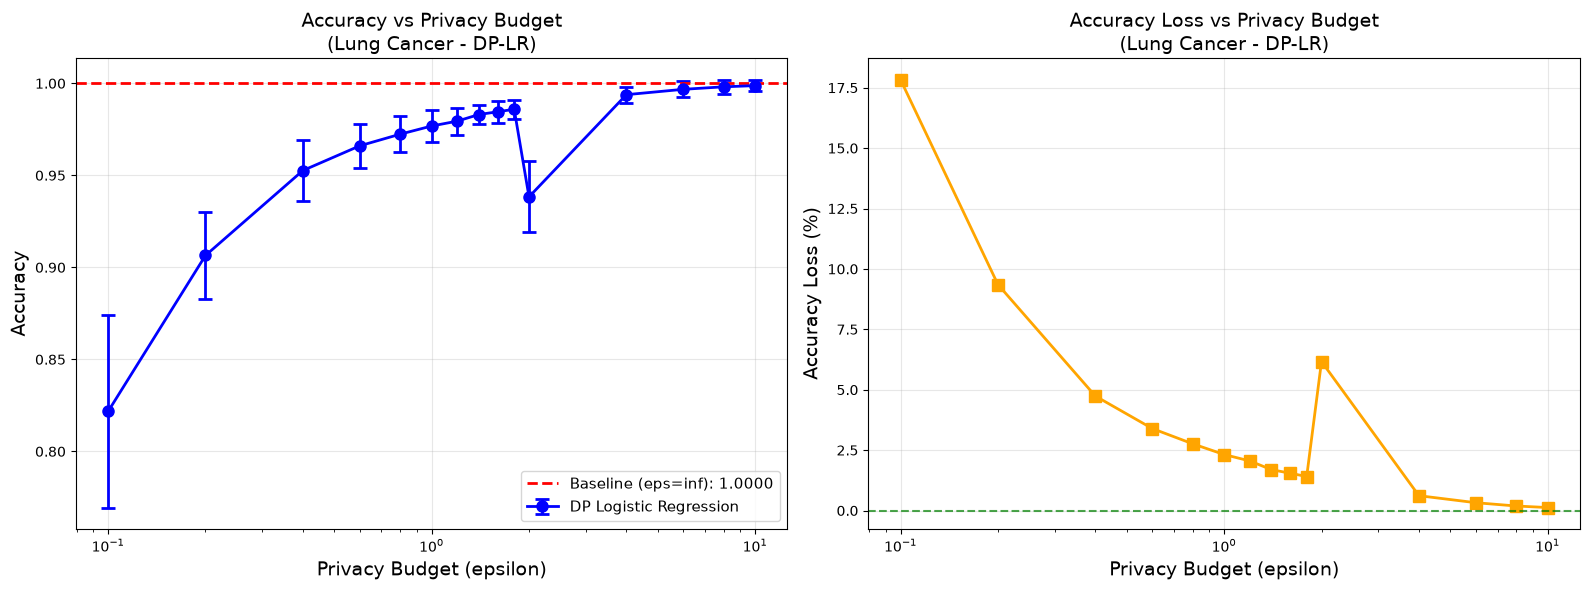

Plot saved to ./output/dp_lr_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Epsilon vs Accuracy with error bars
axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'],
                 marker='o', capsize=5, capthick=2, linewidth=2, markersize=8,
                 label='DP Logistic Regression', color='blue')
if baseline_accuracy is not None:
    axes[0].axhline(y=baseline_accuracy, color='red', linestyle='--',
                    linewidth=2, label=f'Baseline (eps=inf): {baseline_accuracy:.4f}')
axes[0].set_xlabel('Privacy Budget (epsilon)', fontsize=14)
axes[0].set_ylabel('Accuracy', fontsize=14)
axes[0].set_title('Accuracy vs Privacy Budget\n(Lung Cancer - DP-LR)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Subplot 2: Accuracy Loss vs Epsilon
if 'accuracy_loss_pct' in results_df.columns:
    axes[1].plot(results_df['epsilon'], results_df['accuracy_loss_pct'],
                 marker='s', linewidth=2, color='orange', markersize=8)
    axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Privacy Budget (epsilon)', fontsize=14)
    axes[1].set_ylabel('Accuracy Loss (%)', fontsize=14)
    axes[1].set_title('Accuracy Loss vs Privacy Budget\n(Lung Cancer - DP-LR)', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('./output/dp_lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ./output/dp_lr_comparison.png")